In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_foley")
sys.path.append("../models/src_plotting")
# !pip install qutip
from src_foley.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py 
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

In [2]:
chain_length = 2
params = {
    'system_e_levels': np.array([[0, 1]]  * chain_length),
    'photon_freqs': [1],
    'photon_max_nums': [50],
    'mus' : [[[[0, -1], [-1, 0]]] * 3] * chain_length,
    'spatial': True,
    'couplings': None,
    'model': '',
    'positions': [0, 0],
    'descr': "",
    'filepath':None,
    'lambdas':[[0, 0, 1]] * chain_length   
}

mini = 0
maxi = 2
step = 0.01
eigenstates=12
low = 0
high = 2
trials = 20

100%|██████████| 200/200 [00:00<00:00, 394.27it/s]


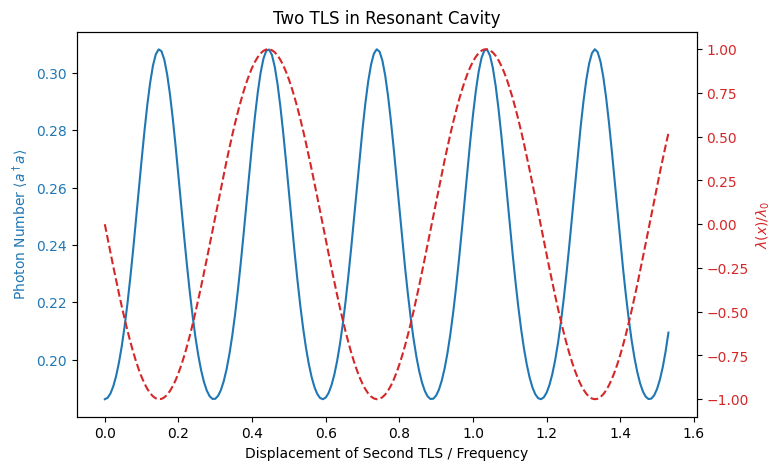

In [12]:
sys_2ls_dist = gen_two_tls_sep(params, mini, maxi, step)
plot_aa_2gx(sys_2ls_dist, 0, mini, maxi, step, xlabel = "Displacement of Second TLS / Frequency",
            title = "Two TLS in Resonant Cavity", model="")

100%|██████████| 200/200 [00:00<00:00, 337.18it/s]


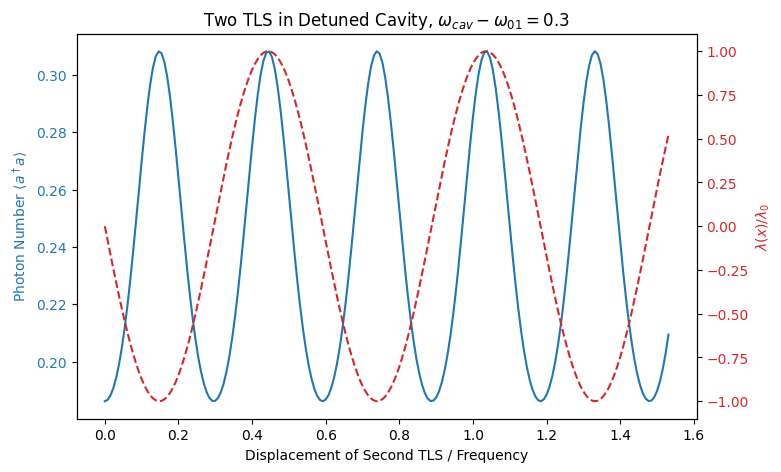

In [13]:
params['photon_freqs'] = [1.3]
sys_2ls_dist = gen_two_tls_sep(params, mini, maxi, step)
plot_aa_2gx(sys_2ls_dist, 0, mini, maxi, step, xlabel = "Displacement of Second TLS / Frequency",
            title = "Two TLS in Detuned Cavity, $\omega_{cav} - \omega_{01} = 0.3$", model="")

100%|██████████| 200/200 [00:02<00:00, 85.88it/s]


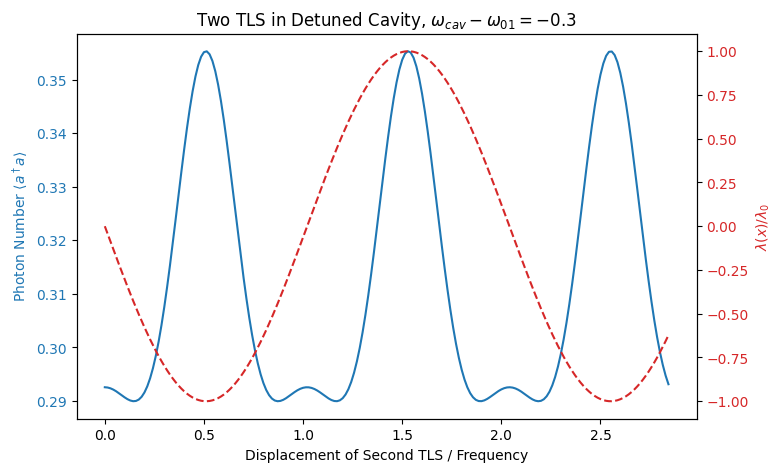

In [24]:
params['photon_freqs'] = [0.7]
params['lambdas'] = [[0, 0, 1]] * chain_length
sys_2ls_dist = gen_two_tls_sep(params, mini, maxi, step)
plot_aa_2gx(sys_2ls_dist, 0, mini, maxi, step, xlabel = "Displacement of Second TLS / Frequency",
            title = "Two TLS in Detuned Cavity, $\omega_{cav} - \omega_{01} = -0.3$", model="")

In [82]:
params = {
    'photon_freqs': [1],
    'photon_max_nums': [25],
    'spatial': True,
    'couplings': None,
    'model': '',
    'positions': [0, 0],
    'descr': "",
    'filepath':None, 
}

100%|██████████| 200/200 [02:43<00:00,  1.22it/s]


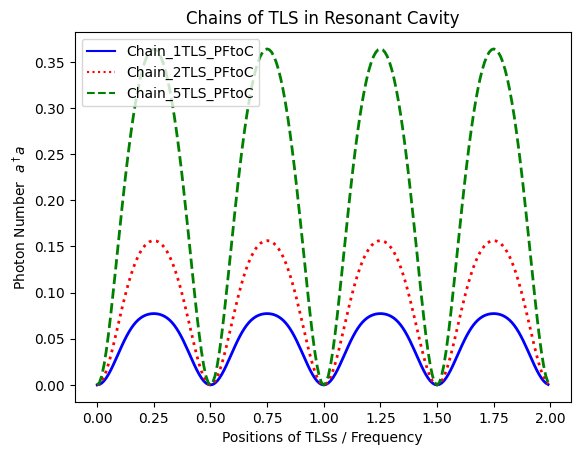

In [83]:
systems_s = []
chain_lengths = [1, 2, 5]
models_s = []
mini = 0
maxi = 2 
step = 0.01 
for chain_length in chain_lengths:
    params['lambdas'] = [[0, 0, 1]] * chain_length
    params['system_e_levels'] =  np.array([[0, 1]]  * chain_length)
    params['mus'] = [[[[0, -1], [-1, 0]]] * 3] * chain_length
    
    systems_cur = gen_mult_tls_trans(params, mini, maxi, step)
    systems_s.append(systems_cur)
    models_s.append("Chain_{}TLS_PFtoC".format(chain_length))

states = [0]
plot_compare(systems_s, states, mini, maxi, step, 
             xlabel="Positions of TLSs / Frequency", 
             ylabel="Photon Number  $a^\dagger a$",
             title = "Chains of TLS in Resonant Cavity",
             lims=[], operator="pn", models_s=models_s)

100%|██████████| 200/200 [02:41<00:00,  1.24it/s]


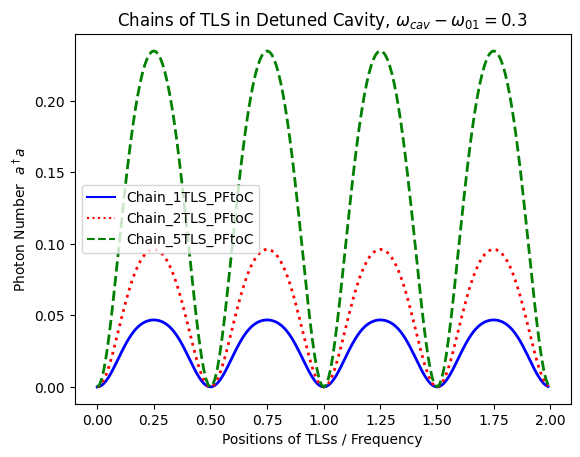

In [84]:
systems_s = []
chain_lengths = [1, 2, 5]
params['photon_freqs'][0] = 1.3
mini = 0
maxi = 2 / params['photon_freqs'][0]
step = 0.01 / params['photon_freqs'][0]

for chain_length in chain_lengths:
    params['lambdas'] = [[0, 0, 1]] * chain_length
    params['system_e_levels'] =  np.array([[0, 1]]  * chain_length)
    params['mus'] = [[[[0, -1], [-1, 0]]] * 3] * chain_length
    
    systems_cur = gen_mult_tls_trans(params, mini, maxi, step)
    systems_s.append(systems_cur)
    models_s.append("Chain_{}TLS_PFtoC".format(chain_length))

states = [0]
mini *= params['photon_freqs'][0]
maxi *= params['photon_freqs'][0]
step *= params['photon_freqs'][0]
plot_compare(systems_s, states, mini, maxi, step, 
             xlabel="Positions of TLSs / Frequency", 
             ylabel="Photon Number  $a^\dagger a$",
             title = "Chains of TLS in Detuned Cavity, $\omega_{cav} - \omega_{01} = 0.3$",
             lims=[], operator="pn", models_s=models_s)

100%|██████████| 200/200 [02:43<00:00,  1.22it/s]


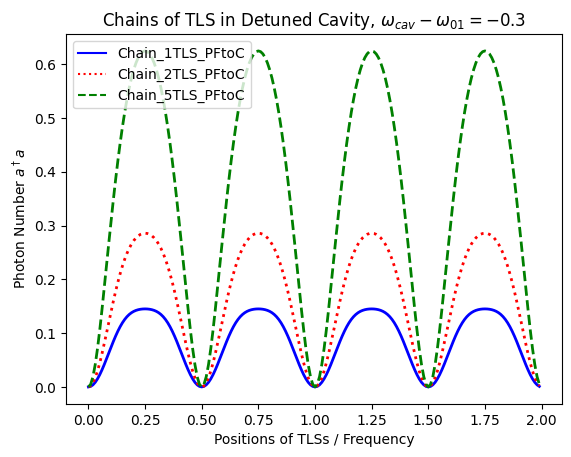

In [85]:
systems_s = []
chain_lengths = [1, 2, 5]
params['photon_freqs'][0] = 0.7
mini = 0
maxi = 2 / params['photon_freqs'][0]
step = 0.01 / params['photon_freqs'][0]

for chain_length in chain_lengths:
    params['lambdas'] = [[0, 0, 1]] * chain_length
    params['system_e_levels'] =  np.array([[0, 1]]  * chain_length)
    params['mus'] = [[[[0, -1], [-1, 0]]] * 3] * chain_length
    
    systems_cur = gen_mult_tls_trans(params, mini, maxi, step)
    systems_s.append(systems_cur)
    models_s.append("Chain_{}TLS_PFtoC".format(chain_length))

states = [0]
mini *= params['photon_freqs'][0]
maxi *= params['photon_freqs'][0]
step *= params['photon_freqs'][0]
plot_compare(systems_s, states, mini, maxi, step, 
             xlabel="Positions of TLSs / Frequency", 
             ylabel="Photon Number $a^\dagger a$",
             title = "Chains of TLS in Detuned Cavity, $\omega_{cav} - \omega_{01} = -0.3$",
             lims=[], operator="pn", models_s=models_s)

In [5]:
chain_length = 2
params = {
    'system_e_levels': np.array([[0, 1]]  * chain_length),
    'photon_freqs': [1],
    'photon_max_nums': [50],
    'mus' : [[[[0, -1], [-1, 0]]] * 3] * chain_length,
    'spatial': True,
    'couplings': None,
    'model': '',
    'positions': [0, 0],
    'descr': "",
    'filepath':None,
    'lambdas':[[0, 0, 1]] * chain_length   
}
eigenstates=12

In [9]:
systems_s = []
chain_lengths = [1, 2, 3, 4, 5]
models_s = []
mini = 0
maxi = 3
step = 0.1
for chain_length in chain_lengths:
    params['lambdas'] = [[0, 0, 1]] * chain_length
    params['system_e_levels'] =  np.array([[0, 1]]  * chain_length)
    params['mus'] = [[[[0, -1], [-1, 0]]] * 3] * chain_length
    
    systems_cur =get_hamiltonians(params, chain_length, mini , maxi, step)
    systems_s.append(systems_cur)
    models_s.append("Chain_{}TLS_PFtoC".format(chain_length))


100%|██████████| 30/30 [00:00<00:00, 397.98it/s]


100%|██████████| 30/30 [03:44<00:00,  7.48s/it]


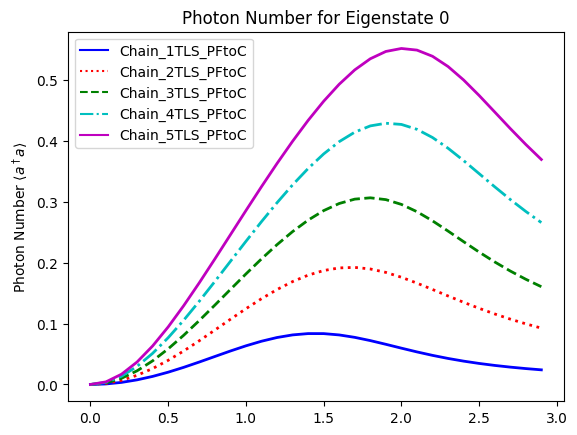

In [12]:
plot_compare(systems_s, [0], mini, maxi, step, 
                 omega = 1, norm_state=None, xlabel="", lims=[], operator="pn", models_s=models_s)

100%|██████████| 30/30 [03:24<00:00,  6.80s/it]


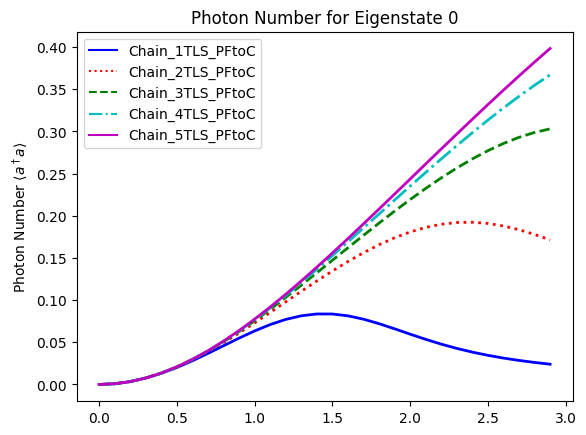

In [14]:
systems_s = []
chain_lengths = [1, 2, 3, 4, 5]
models_s = []
mini = 0
maxi = 3
step = 0.1
for chain_length in chain_lengths:
    params['lambdas'] = [[0, 0, 1]] * chain_length
    params['system_e_levels'] =  np.array([[0, 1]]  * chain_length)
    params['mus'] = [[[[0, -1], [-1, 0]]] * 3] * chain_length
    
    systems_cur =get_hamiltonians(params, chain_length, mini , maxi, step)
    systems_s.append(systems_cur)
    models_s.append("Chain_{}TLS_PFtoC".format(chain_length))


plot_compare(systems_s, [0], mini, maxi, step, 
                 omega = 1, norm_state=None, xlabel="", lims=[], operator="pn", models_s=models_s)